## HealthLens: Revealing the Hidden Dimensions of Lifestyle Data

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("D:\Imarticus\ML\Sleep_health_and_lifestyle_dataset.csv")

In [3]:
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [4]:
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [5]:
df.tail()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
373,374,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


In [6]:
df.shape

(374, 13)

In [7]:
df.columns

Index(['Person ID', 'Gender', 'Age', 'Occupation', 'Sleep Duration',
       'Quality of Sleep', 'Physical Activity Level', 'Stress Level',
       'BMI Category', 'Blood Pressure', 'Heart Rate', 'Daily Steps',
       'Sleep Disorder'],
      dtype='object')

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [9]:
df.describe()

,Person ID,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
count,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000,374.000000
mean,187.500000,42.184492,7.132086,7.312834,59.171123,5.385027,70.165775,6816.844920
std,108.108742,8.673133,0.795657,1.196956,20.830804,1.774526,4.135676,1617.915679
min,1.000000,27.000000,5.800000,4.000000,30.000000,3.000000,65.000000,3000.000000
25%,94.250000,35.250000,6.400000,6.000000,45.000000,4.000000,68.000000,5600.000000
50%,187.500000,43.000000,7.200000,7.000000,60.000000,5.000000,70.000000,7000.000000
75%,280.750000,50.000000,7.800000,8.000000,75.000000,7.000000,72.000000,8000.000000
max,374.000000,59.000000,8.500000,9.000000,90.000000,8.000000,86.000000,10000.000000


In [10]:
df.isnull().sum()

Person ID                    0
Gender                       0
Age                          0
Occupation                   0
Sleep Duration               0
Quality of Sleep             0
Physical Activity Level      0
Stress Level                 0
BMI Category                 0
Blood Pressure               0
Heart Rate                   0
Daily Steps                  0
Sleep Disorder             219
dtype: int64

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
for col in df.columns:
    print("\n", col)
    print(df[col].unique())


 Person ID
[  1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17  18
  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35  36
  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53  54
  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71  72
  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89  90
  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107 108
 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125 126
 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143 144
 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161 162
 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179 180
 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197 198
 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215 216
 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233 234
 235 236 237 238 239 240 241 242 243 24

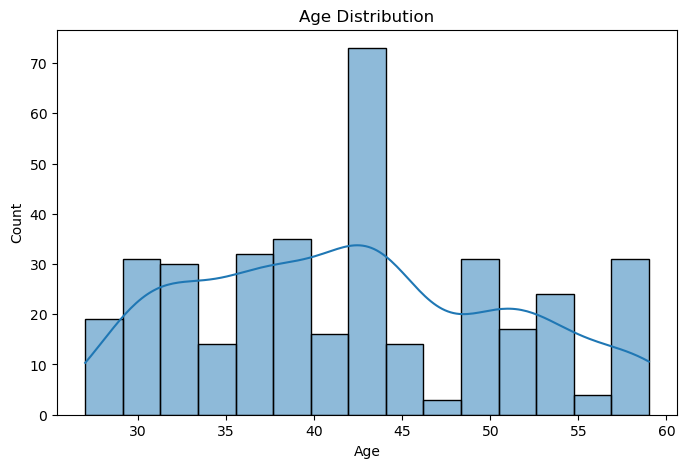

In [13]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=15, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

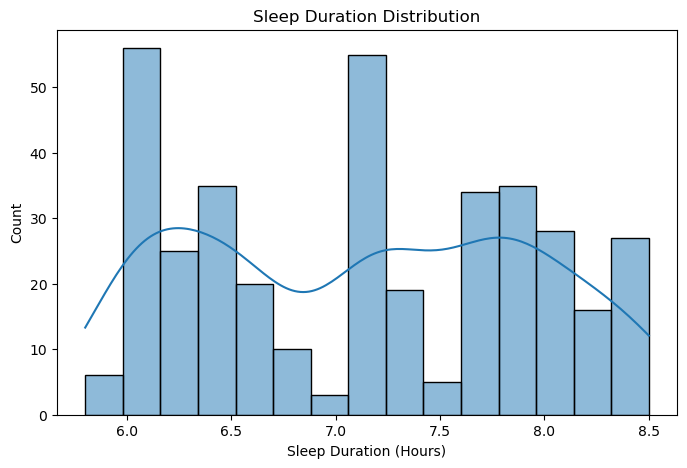

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["Sleep Duration"], bins=15, kde=True)

plt.title("Sleep Duration Distribution")
plt.xlabel("Sleep Duration (Hours)")
plt.ylabel("Count")
plt.show()

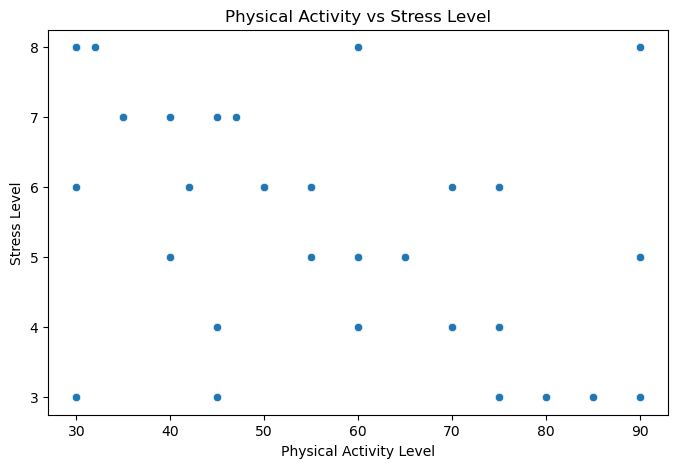

In [15]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Physical Activity Level",
    y="Stress Level"
)

plt.title("Physical Activity vs Stress Level")
plt.xlabel("Physical Activity Level")
plt.ylabel("Stress Level")
plt.show()

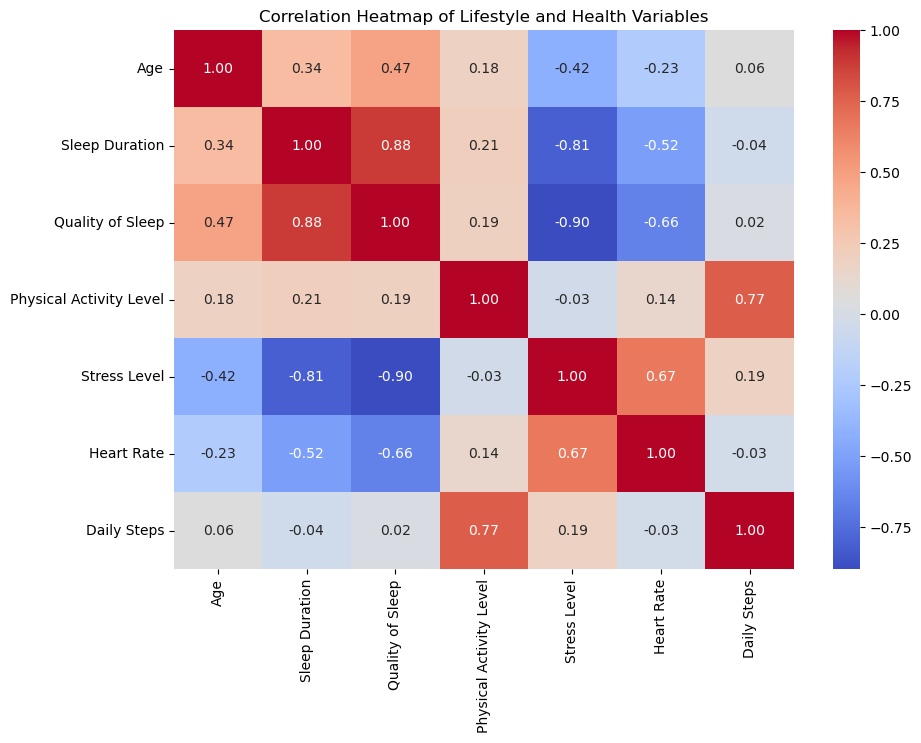

In [16]:
numeric_cols = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

plt.figure(figsize=(10,7))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Lifestyle and Health Variables")

plt.show()

In [17]:
features = [
    "Age",
    "Sleep Duration",
    "Quality of Sleep",
    "Physical Activity Level",
    "Stress Level",
    "Heart Rate",
    "Daily Steps"
]

In [18]:
X = df[features]

In [19]:
X.head()

,Age,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,Heart Rate,Daily Steps
0,27,6.1,6,42,6,77,4200
1,28,6.2,6,60,8,75,10000
2,28,6.2,6,60,8,75,10000
3,28,5.9,4,30,8,85,3000
4,28,5.9,4,30,8,85,3000


In [20]:
X.isnull().sum()

Age                        0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
Heart Rate                 0
Daily Steps                0
dtype: int64

In [21]:
X = X.fillna(X.median())

In [22]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [23]:
X_scaled[:5]

array([[-1.75309569, -1.29888693, -1.09828011, -0.82541823,  0.34702051,
         1.6547187 , -1.61958404],
       [-1.63764266, -1.17303623, -1.09828011,  0.03984423,  1.47559156,
         1.17047394,  1.97007745],
       [-1.63764266, -1.17303623, -1.09828011,  0.03984423,  1.47559156,
         1.17047394,  1.97007745],
       [-1.63764266, -1.55058833, -2.77142374, -1.40225988,  1.47559156,
         3.5916977 , -2.36227262],
       [-1.63764266, -1.55058833, -2.77142374, -1.40225988,  1.47559156,
         3.5916977 , -2.36227262]])

In [24]:
pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [25]:
X_pca.shape

(374, 7)

In [26]:
explained_variance = pca.explained_variance_ratio_

print(explained_variance)

[0.49767263 0.26046992 0.11356471 0.08509536 0.02247409 0.01266022
 0.00806308]


In [27]:
cumulative_variance = np.cumsum(explained_variance)

print(cumulative_variance)

[0.49767263 0.75814254 0.87170726 0.95680261 0.9792767  0.99193692
 1.        ]


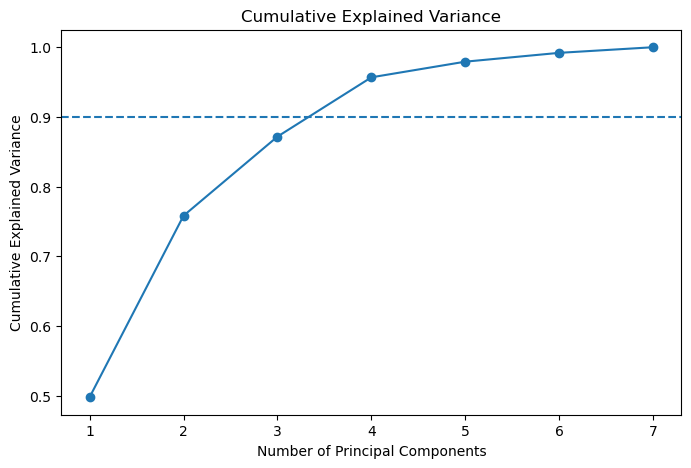

In [28]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(explained_variance) + 1),
    cumulative_variance,
    marker="o"
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.axhline(
    y=0.90,
    linestyle="--"
)

plt.show()

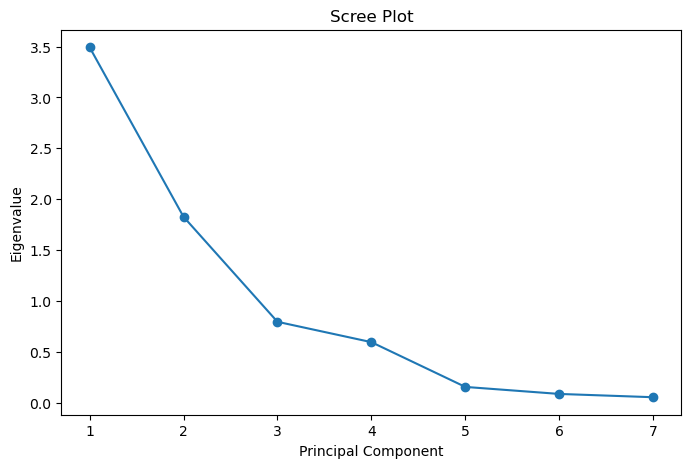

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1, len(pca.explained_variance_) + 1),
    pca.explained_variance_,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Eigenvalue")
plt.title("Scree Plot")

plt.show()

In [30]:
n_components = np.argmax(cumulative_variance >= 0.90) + 1

print("Number of components:", n_components)

Number of components: 4


In [31]:
pca_final = PCA(n_components=n_components)

X_pca_final = pca_final.fit_transform(X_scaled)

In [32]:
X_pca_final.shape

(374, 4)

In [33]:
pca_columns = [
    f"PC{i+1}"
    for i in range(n_components)
]

pca_df = pd.DataFrame(
    X_pca_final,
    columns=pca_columns
)

pca_df.head()

,PC1,PC2,PC3,PC4
0,-2.599071,-1.686001,-0.232173,1.295336
1,-2.817452,1.468414,-1.175076,-0.130050
2,-2.817452,1.468414,-1.175076,-0.130050
3,-4.933235,-2.233814,1.015186,2.155814
4,-4.933235,-2.233814,1.015186,2.155814


In [34]:
for i, variance in enumerate(
    pca_final.explained_variance_ratio_
):
    print(
        f"PC{i+1}: {variance:.2%}"
    )

PC1: 49.77%
PC2: 26.05%
PC3: 11.36%
PC4: 8.51%


In [35]:
print(
    "Total explained variance:",
    pca_final.explained_variance_ratio_.sum()
)

Total explained variance: 0.9568026127581015


In [36]:
loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=pca_columns,
    index=features
)

loadings

,PC1,PC2,PC3,PC4
Age,0.292874,0.120679,0.862184,-0.369455
Sleep Duration,0.478768,0.017767,-0.090757,0.447326
Quality of Sleep,0.519330,0.024210,-0.042791,0.122534
Physical Activity Level,0.086474,0.695260,0.004196,0.282749
Stress Level,-0.501988,0.125938,0.033935,-0.130774
Heart Rate,-0.394742,0.129345,0.433098,0.660728
Daily Steps,-0.003313,0.684513,-0.240476,-0.338789


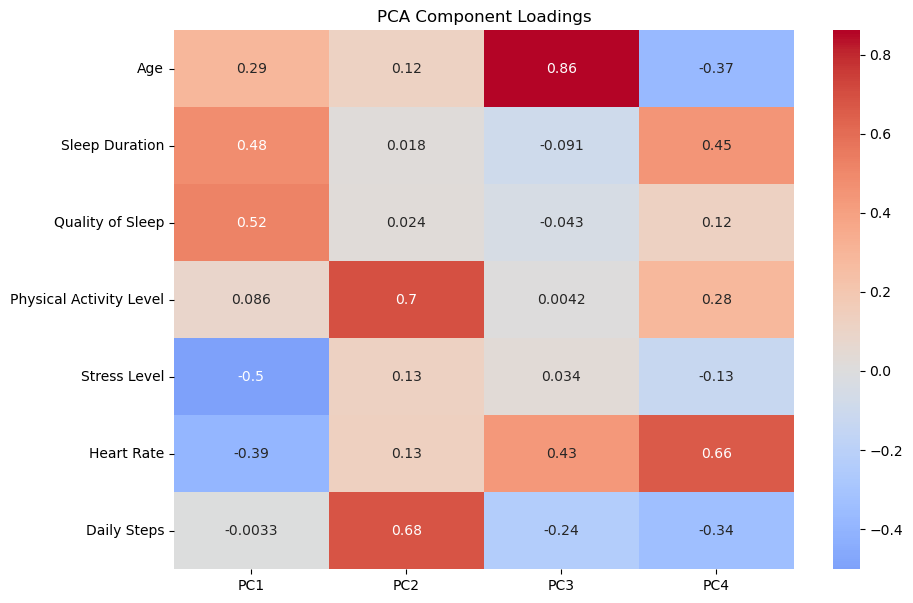

In [37]:
plt.figure(figsize=(10,7))

sns.heatmap(
    loadings,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("PCA Component Loadings")

plt.show()

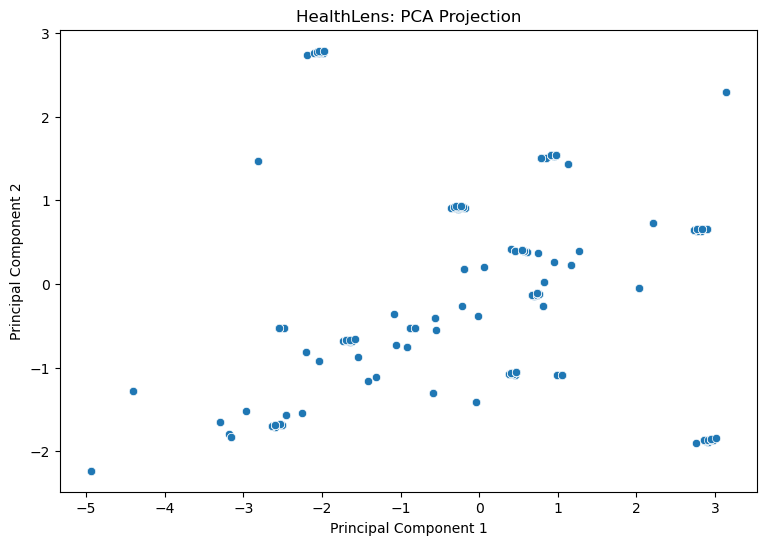

In [38]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    x=pca_df["PC1"],
    y=pca_df["PC2"]
)

plt.title("HealthLens: PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [39]:
pca_df["Sleep Disorder"] = df["Sleep Disorder"].values

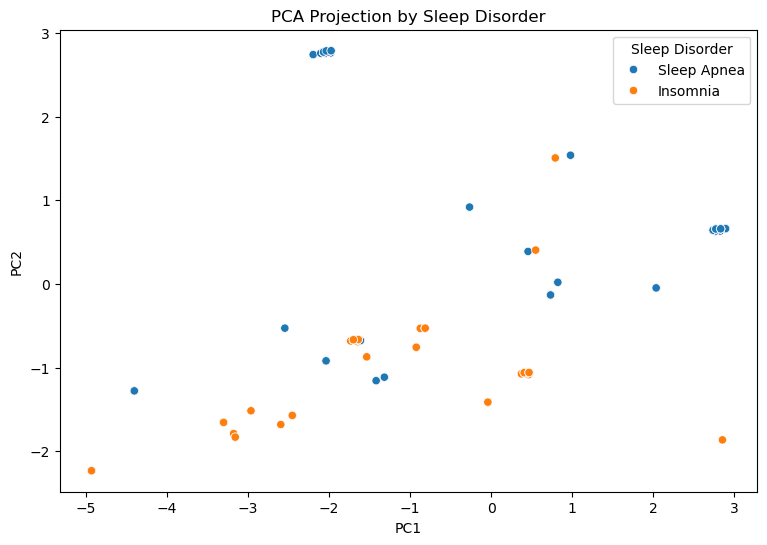

In [40]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Sleep Disorder"
)

plt.title("PCA Projection by Sleep Disorder")

plt.show()

In [41]:
pca_df["BMI Category"] = df["BMI Category"].values

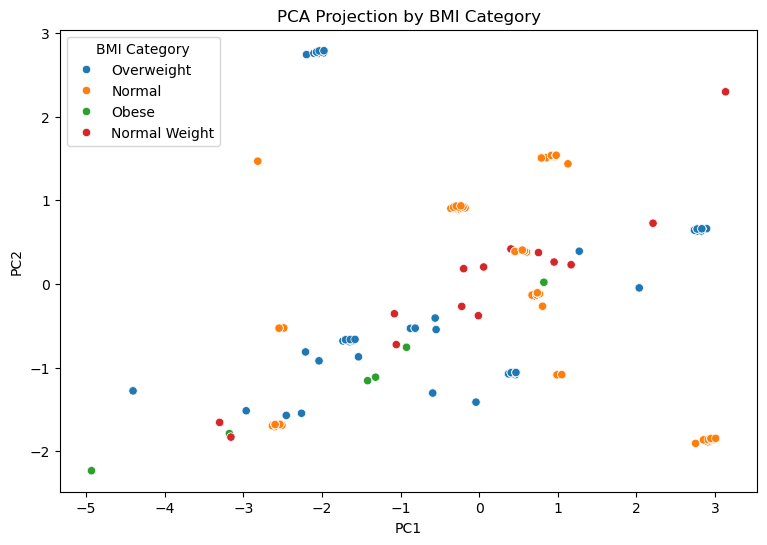

In [42]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="BMI Category"
)

plt.title("PCA Projection by BMI Category")

plt.show()

In [43]:
pca_summary = pd.DataFrame({
    "Component": pca_columns,
    "Explained Variance": pca_final.explained_variance_ratio_,
    "Cumulative Variance": np.cumsum(
        pca_final.explained_variance_ratio_
    )
})

pca_summary

,Component,Explained Variance,Cumulative Variance
0,PC1,0.497673,0.497673
1,PC2,0.260470,0.758143
2,PC3,0.113565,0.871707
3,PC4,0.085095,0.956803


In [44]:
for pc in pca_columns:
    
    print("\n", pc)
    
    print(
        loadings[pc]
        .sort_values(
            key=abs,
            ascending=False
        )
    )


 PC1
Quality of Sleep           0.519330
Stress Level              -0.501988
Sleep Duration             0.478768
Heart Rate                -0.394742
Age                        0.292874
Physical Activity Level    0.086474
Daily Steps               -0.003313
Name: PC1, dtype: float64

 PC2
Physical Activity Level    0.695260
Daily Steps                0.684513
Heart Rate                 0.129345
Stress Level               0.125938
Age                        0.120679
Quality of Sleep           0.024210
Sleep Duration             0.017767
Name: PC2, dtype: float64

 PC3
Age                        0.862184
Heart Rate                 0.433098
Daily Steps               -0.240476
Sleep Duration            -0.090757
Quality of Sleep          -0.042791
Stress Level               0.033935
Physical Activity Level    0.004196
Name: PC3, dtype: float64

 PC4
Heart Rate                 0.660728
Sleep Duration             0.447326
Age                       -0.369455
Daily Steps               -0.33878

In [45]:
final_dataset = pca_df[pca_columns]

final_dataset.head()

,PC1,PC2,PC3,PC4
0,-2.599071,-1.686001,-0.232173,1.295336
1,-2.817452,1.468414,-1.175076,-0.130050
2,-2.817452,1.468414,-1.175076,-0.130050
3,-4.933235,-2.233814,1.015186,2.155814
4,-4.933235,-2.233814,1.015186,2.155814


In [46]:
final_dataset.to_csv(
    "HealthLens_PCA_Dataset.csv",
    index=False
)

### Conclusion

The **HealthLens: Revealing the Hidden Dimensions of Lifestyle Data** project successfully used **Principal Component Analysis (PCA)** to reduce multiple lifestyle and health-related variables into a smaller number of meaningful components. After standardizing the data, PCA identified the major patterns present in variables such as sleep duration, sleep quality, physical activity, stress level, heart rate, daily steps, and age.

The analysis showed that a small number of principal components can preserve most of the important information from the original dataset. The PCA loadings also helped identify which lifestyle factors contribute most strongly to each component.

Overall, **HealthLens demonstrates how PCA can simplify complex health and lifestyle data, reveal hidden patterns, reduce dimensionality, and make the dataset easier to visualize and analyze.**
